# 🎬 Chương 3 — Dataset 2: IMDB Reviews — Bidirectional GRU
## Kỹ thuật: GloVe Embeddings + Bidirectional GRU

**Pipeline:** EDA → WordCloud → GloVe Embedding Matrix → BiGRU → Train → Evaluate

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import re, os, glob, warnings

import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

DATA_DIR = '../data/imdb_reviews'
SAVE_DIR = '../results/imdb_bigru'
os.makedirs(SAVE_DIR, exist_ok=True)

VOCAB_SIZE = 20000
MAX_LEN    = 200
EMBED_DIM  = 100   # GloVe 100d
EPOCHS     = 10
BATCH_SIZE = 128

print(f"TF: {tf.__version__} | Seed = {SEED}")

2026-05-09 20:01:39.307829: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 20:01:39.335832: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 20:01:39.800958: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TF: 2.13.0 | Seed = 42


## 📂 1. Load IMDB Data

In [2]:
csv_files = glob.glob(f'{DATA_DIR}/**/*.csv', recursive=True) + glob.glob(f'{DATA_DIR}/*.csv')
print('Found:', csv_files)
df = pd.read_csv(csv_files[0])
print(f'Shape: {df.shape}')
df.head(3)

Found: ['../data/imdb_reviews/IMDB Dataset.csv', '../data/imdb_reviews/IMDB Dataset.csv']
Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


In [3]:
# Identify columns
text_col  = [c for c in df.columns if any(k in c.lower() for k in ['review','text','comment'])][0]
label_col = [c for c in df.columns if any(k in c.lower() for k in ['sentiment','label','rating'])][0]
print(f'Text: {text_col}, Label: {label_col}')
print(df[label_col].value_counts())

df = df[[text_col, label_col]].dropna()
df.columns = ['text', 'label']

# Binary encode
if df['label'].dtype == object:
    positive_keys = ['positive', 'pos', '1', 'good']
    df['label'] = df['label'].str.lower().apply(
        lambda x: 1 if any(k in x for k in positive_keys) else 0)

print(f'Label distribution:\n{df["label"].value_counts()}')

Text: review, Label: sentiment
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Label distribution:
label
1    25000
0    25000
Name: count, dtype: int64


## 📊 2. EDA

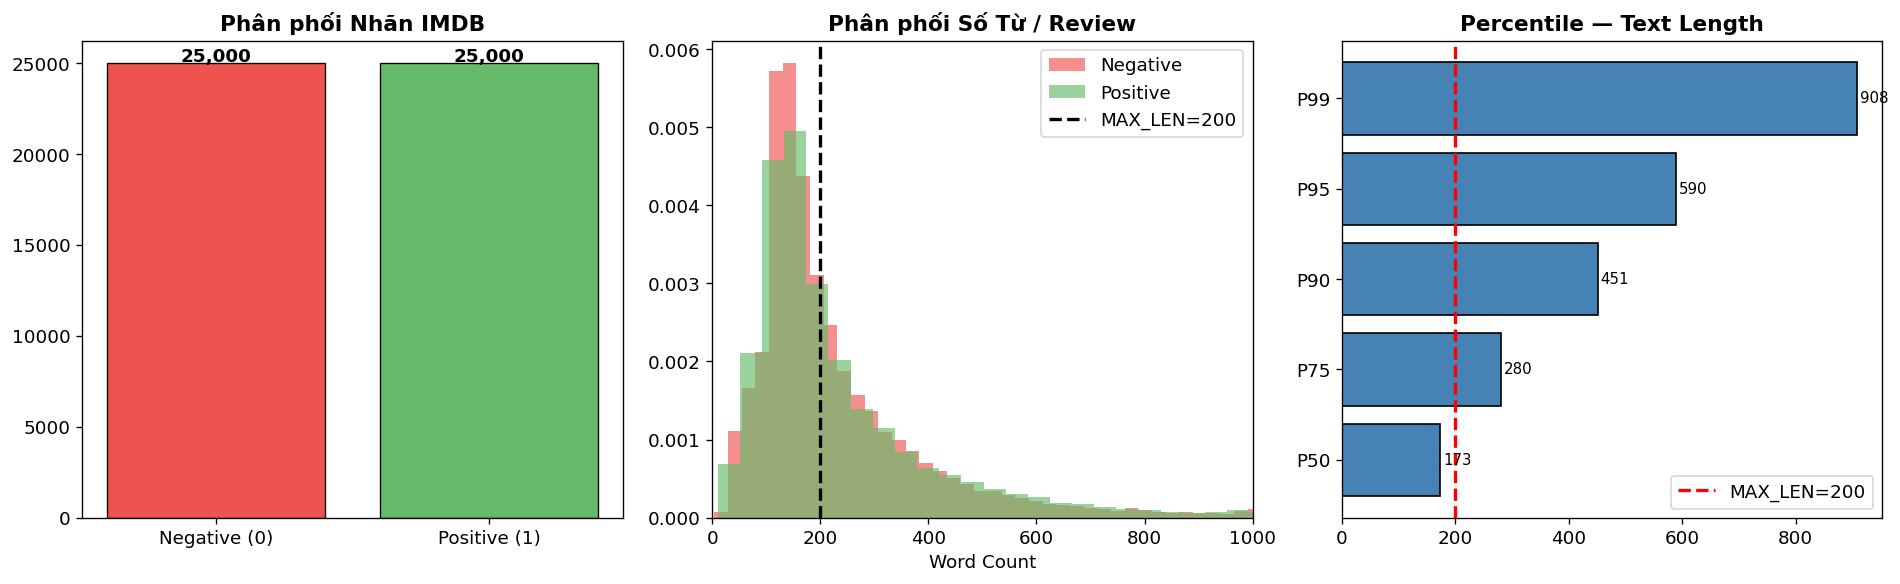

In [4]:
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_len'] = df['text'].apply(lambda x: len(str(x)))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Label counts
counts = df['label'].value_counts().sort_index()
axes[0].bar(['Negative (0)', 'Positive (1)'], counts.values,
            color=['#EF5350', '#66BB6A'], edgecolor='black', linewidth=0.8)
for i, val in enumerate(counts.values):
    axes[0].text(i, val+100, f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Phân phối Nhãn IMDB')

# Word count per sentiment
for lbl, color, name in [(0,'#EF5350','Negative'), (1,'#66BB6A','Positive')]:
    axes[1].hist(df[df['label']==lbl]['text_len'],
                 bins=60, alpha=0.65, color=color, label=name, density=True)
axes[1].axvline(MAX_LEN, color='black', linestyle='--', lw=2, label=f'MAX_LEN={MAX_LEN}')
axes[1].set_title('Phân phối Số Từ / Review')
axes[1].set_xlabel('Word Count')
axes[1].legend()
axes[1].set_xlim(0, 1000)

# Percentile coverage
percentiles = [50, 75, 90, 95, 99]
pct_values  = np.percentile(df['text_len'], percentiles)
axes[2].barh([f'P{p}' for p in percentiles], pct_values,
              color='steelblue', edgecolor='black')
axes[2].axvline(MAX_LEN, color='red', linestyle='--', lw=2, label=f'MAX_LEN={MAX_LEN}')
axes[2].set_title('Percentile — Text Length')
axes[2].legend()
for i, v in enumerate(pct_values):
    axes[2].text(v+5, i, f'{v:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_eda_overview.png', bbox_inches='tight')
plt.show()

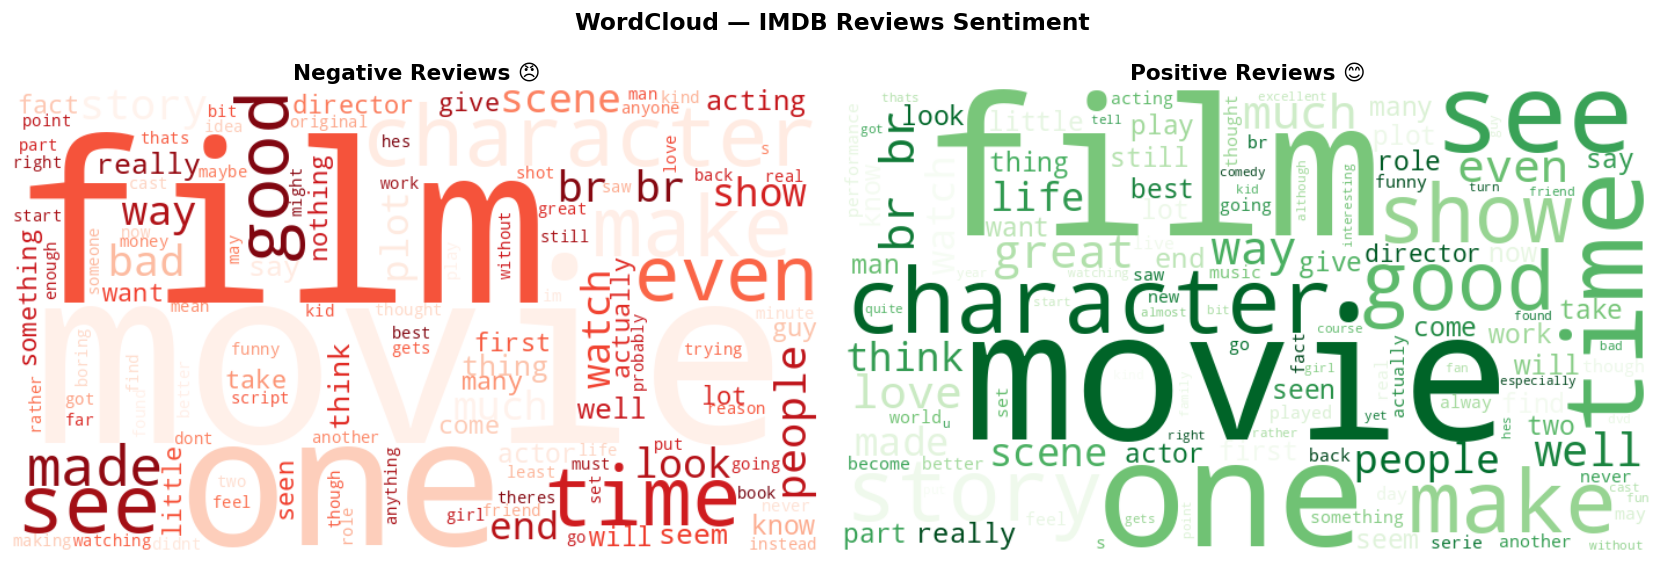

In [5]:
# WordClouds
def clean_text(text):
    return re.sub(r'[^a-z\s]', '', str(text).lower())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (lbl, title, cmap) in zip(axes, [
    (0, 'Negative Reviews 😠', 'Reds'),
    (1, 'Positive Reviews 😊', 'Greens')
]):
    corpus = ' '.join(df[df['label']==lbl]['text'].apply(clean_text).tolist())
    wc = WordCloud(width=700, height=400, max_words=120,
                   colormap=cmap, background_color='white').generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13)

plt.suptitle('WordCloud — IMDB Reviews Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_wordclouds.png', bbox_inches='tight')
plt.show()

## ⚙️ 3. Preprocessing & GloVe Embedding

In [6]:
df['clean'] = df['text'].apply(clean_text)

X = df['clean'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train),
                             maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test),
                             maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Vocab size: {len(tokenizer.word_index):,}')
print(f'Train: {X_train_pad.shape}, Test: {X_test_pad.shape}')

Vocab size: 155,856
Train: (40000, 200), Test: (10000, 200)


In [7]:
# Try to load GloVe — fallback to trainable embedding
GLOVE_PATH = os.path.expanduser('~/glove.6B.100d.txt')
embedding_matrix = None

if os.path.exists(GLOVE_PATH):
    print('Loading GloVe embeddings...')
    glove_dict = {}
    with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.split()
            glove_dict[parts[0]] = np.array(parts[1:], dtype='float32')

    embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
    hits = 0
    for word, idx in tokenizer.word_index.items():
        if idx < VOCAB_SIZE and word in glove_dict:
            embedding_matrix[idx] = glove_dict[word]
            hits += 1
    print(f'GloVe hit rate: {hits}/{min(VOCAB_SIZE, len(tokenizer.word_index)):,} words ({hits/min(VOCAB_SIZE, len(tokenizer.word_index))*100:.1f}%)')
    USE_GLOVE = True
else:
    print('⚠️  GloVe not found — using trainable embedding instead.')
    print('   (Download: https://nlp.stanford.edu/data/glove.6B.zip)')
    USE_GLOVE = False

⚠️  GloVe not found — using trainable embedding instead.
   (Download: https://nlp.stanford.edu/data/glove.6B.zip)


## 🏗️ 4. Bidirectional GRU Model

In [8]:
# Build embedding layer
if USE_GLOVE and embedding_matrix is not None:
    embed_layer = layers.Embedding(
        VOCAB_SIZE, EMBED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False,   # Frozen GloVe
        name='glove_embedding'
    )
else:
    embed_layer = layers.Embedding(
        VOCAB_SIZE, EMBED_DIM,
        input_length=MAX_LEN,
        trainable=True,
        name='trainable_embedding'
    )

model = models.Sequential([
    embed_layer,
    layers.SpatialDropout1D(0.2),
    layers.Bidirectional(layers.GRU(64, return_sequences=True), name='bigru_1'),
    layers.Dropout(0.3),
    layers.Bidirectional(layers.GRU(32), name='bigru_2'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid', name='output')
], name='BiGRU_IMDB')

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

2026-05-09 20:02:01.534948: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-09 20:02:01.536259: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-09 20:02:01.537543: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Model: "BiGRU_IMDB"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 trainable_embedding (Embed  (None, 200, 100)          2000000   
 ding)                                                           
                                                                 
 spatial_dropout1d (Spatial  (None, 200, 100)          0         
 Dropout1D)                                                      
                                                                 
 bigru_1 (Bidirectional)     (None, 200, 128)          63744     
                                                                 
 dropout (Dropout)           (None, 200, 128)          0         
                                                                 
 bigru_2 (Bidirectional)     (None, 64)                31104     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0

## 🚀 5. Training

In [9]:
history = model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
    ],
    verbose=1
)

Epoch 1/10
266/266 [==============================] - 34s 118ms/step - loss: 0.4896 - accuracy: 0.7425 - val_loss: 0.3218 - val_accuracy: 0.8657 - lr: 0.0010
Epoch 2/10
266/266 [==============================] - 31s 117ms/step - loss: 0.2605 - accuracy: 0.8997 - val_loss: 0.3266 - val_accuracy: 0.8667 - lr: 0.0010
Epoch 3/10
266/266 [==============================] - ETA: 0s - loss: 0.1750 - accuracy: 0.9369
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
266/266 [==============================] - 30s 114ms/step - loss: 0.1750 - accuracy: 0.9369 - val_loss: 0.3320 - val_accuracy: 0.8628 - lr: 0.0010
Epoch 4/10
266/266 [==============================] - 31s 115ms/step - loss: 0.0960 - accuracy: 0.9706 - val_loss: 0.3898 - val_accuracy: 0.8622 - lr: 5.0000e-04


## 📈 6. Evaluation

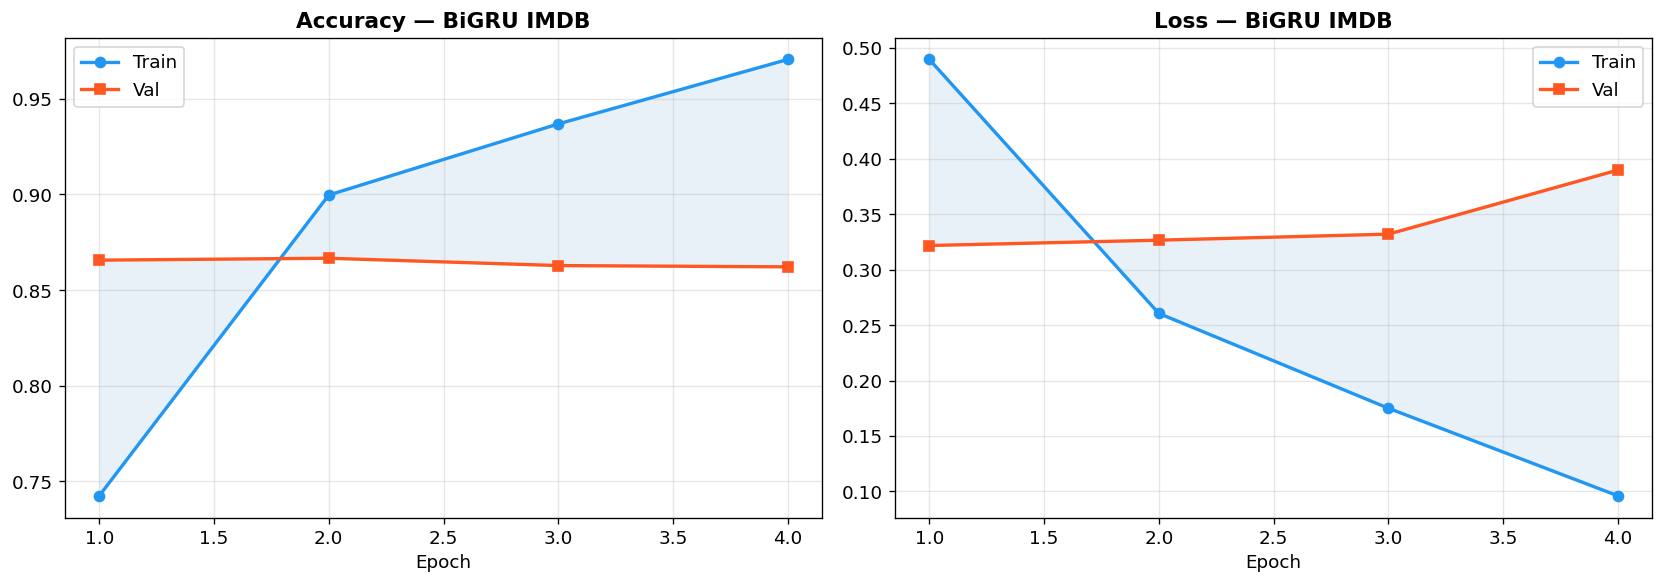

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eps = range(1, len(history.history['accuracy'])+1)
for ax, (tr, vl, metric) in zip(axes, [
    ('accuracy','val_accuracy','Accuracy'),
    ('loss','val_loss','Loss')
]):
    ax.plot(eps, history.history[tr], 'o-', color='#2196F3', lw=2, label='Train')
    ax.plot(eps, history.history[vl], 's-', color='#FF5722', lw=2, label='Val')
    ax.fill_between(eps, history.history[tr], history.history[vl], alpha=0.1)
    ax.set_title(f'{metric} — BiGRU IMDB')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_training_history.png', bbox_inches='tight')
plt.show()

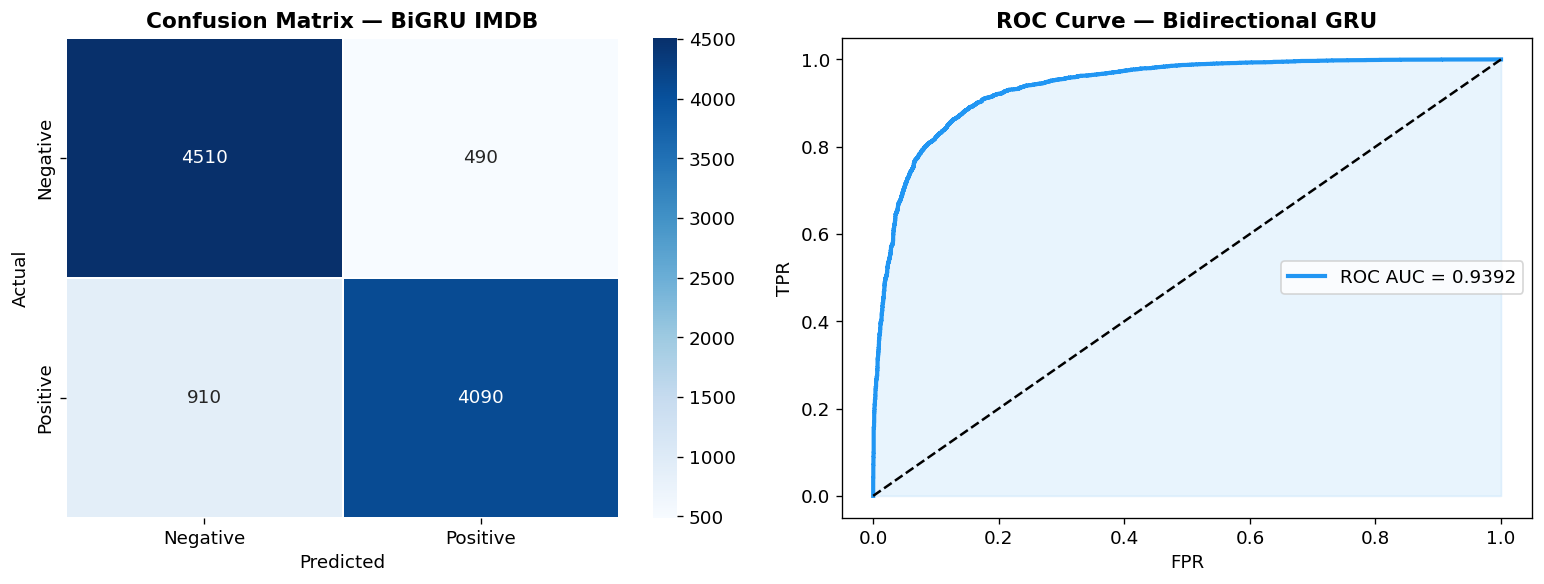

              precision    recall  f1-score   support

    Negative       0.83      0.90      0.87      5000
    Positive       0.89      0.82      0.85      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [11]:
y_pred_prob = model.predict(X_test_pad, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc     = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'],
            linewidths=1, ax=axes[0])
axes[0].set_title('Confusion Matrix — BiGRU IMDB')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# ROC Curve
axes[1].plot(fpr, tpr, color='#2196F3', lw=2.5, label=f'ROC AUC = {roc_auc:.4f}')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
axes[1].plot([0,1],[0,1],'k--', lw=1.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve — Bidirectional GRU'); axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_confusion_roc.png', bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Negative','Positive']))

In [12]:
# Inference demo on new sentences
test_samples = [
    "This movie was absolutely fantastic! The acting was superb.",
    "Terrible film. Complete waste of time and money.",
    "It was okay, nothing special but not bad either."
]

cleaned  = [clean_text(s) for s in test_samples]
seqs     = pad_sequences(tokenizer.texts_to_sequences(cleaned),
                          maxlen=MAX_LEN, padding='post')
scores   = model.predict(seqs, verbose=0).flatten()

print('=== INFERENCE DEMO ===')
for s, score in zip(test_samples, scores):
    label = 'POSITIVE 😊' if score >= 0.5 else 'NEGATIVE 😠'
    print(f'Text  : {s[:60]}...')
    print(f'Score : {score:.4f} → {label}\n')

=== INFERENCE DEMO ===
Text  : This movie was absolutely fantastic! The acting was superb....
Score : 0.8746 → POSITIVE 😊

Text  : Terrible film. Complete waste of time and money....
Score : 0.0207 → NEGATIVE 😠

Text  : It was okay, nothing special but not bad either....
Score : 0.0997 → NEGATIVE 😠



In [13]:
best_acc = max(history.history['val_accuracy'])
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('IMDB Reviews — Bidirectional GRU\n' + '='*50 + '\n')
    f.write(f'GloVe: {USE_GLOVE}\n')
    f.write(f'Best Val Accuracy: {best_acc:.4f}\n')
    f.write(f'ROC-AUC: {roc_auc:.4f}\n')
    f.write(f'Total Params: {model.count_params():,}\n\n')
    f.write(classification_report(y_test, y_pred, target_names=['Negative','Positive']))

print('✅ IMDB BiGRU Experiment Done! Saved to', SAVE_DIR)

✅ IMDB BiGRU Experiment Done! Saved to ../results/imdb_bigru
